# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [5]:
!pip install torch torchvision ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git
!pip install scikit-learn matplotlib pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-bj5wefvp
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-bj5wefvp
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=349640662110ac14ad8138b9c53e5e9bc12dc172ca2a06badcf7165a0c35e689
  Stored in directory: /tmp/pip-ephem-wheel-cache-_915on5c/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


Aqui van los importes

In [6]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics.pairwise import cosine_similarity
import urllib.request


Usamos pytorch

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
print("Dispositivo:", device)


100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 290MiB/s]


Dispositivo: cuda


Las imágenes se encuentran en la web, así que las cargamos usando su URL.

#### 1. Obtener embeddings de imágenes y textos con CLIP.

In [8]:
import os
base_path = '/kaggle/input/imagenesri/RI' 

image_paths = []
image_names = [] # Guardamos nombres para las gráficas

# Recorremos tu carpeta
for filename in os.listdir(base_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        full_path = os.path.join(base_path, filename)
        image_paths.append(full_path)
        image_names.append(filename)

print(f"Se encontraron {len(image_paths)} imágenes en tu dataset.")
# Ordenamos para mantener consistencia
image_paths.sort()
image_names.sort()

Se encontraron 18 imágenes en tu dataset.


Cargamos las imágenes en un conjunto de datos (lista). Después utilizamos torch para obtener los embeddings de las imágenes.

In [9]:
images = [
    preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
    for p in image_paths
]

with torch.no_grad():
    image_embeddings = torch.cat([model.encode_image(img) for img in images])

image_embeddings /= image_embeddings.norm(dim=-1, keepdim=True)

print("Embeddings de imágenes:", image_embeddings.shape)


Embeddings de imágenes: torch.Size([18, 512])


Creamos una lista de textos y obtenemos sus embeddings.

In [48]:
texts = [
    # Categorías generales (Plantillas)
    "a photo of a dog",
    "a photo of a cat",
    "a photo of a car",
    "a photo of an airplane",
    "a photo of delicious food",

    # Descripciones específicas (Para ver si distingue detalles)
    "a person with brown hair",
    "a person smiling",
    "a red vehicle",
    "a white vehicle",
    "a fast jet plane in the sky",
    "a commercial airliner",
    
    # "Distractores" (Cosas que NO están, para probar que no se confunde)
    "a photo of a bicycle",
    "a landscape of a forest",
    "an elephant"
]

text_tokens = clip.tokenize(texts).to(device)

with torch.no_grad():
    text_embeddings = model.encode_text(text_tokens)

text_embeddings /= text_embeddings.norm(dim=-1, keepdim=True)

print("Embeddings de texto:", text_embeddings.shape)


Embeddings de texto: torch.Size([14, 512])


#### 2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).

Comprobamos las dimensiones

In [50]:
print("Dimensión imagen:", image_embeddings.shape[1])
print("Dimensión texto:", text_embeddings.shape[1])


Dimensión imagen: 512
Dimensión texto: 512


Obtenemos la similitud coseno de los embeddings de los textos e imágenes.

In [51]:
similarity = cosine_similarity(
    text_embeddings.cpu().numpy(),
    image_embeddings.cpu().numpy()
)

similarity


array([[0.18837138, 0.22213578, 0.17200791, 0.18466929, 0.17149981,
        0.17462537, 0.16366184, 0.17059515, 0.17072985, 0.22851221,
        0.22629425, 0.25419582, 0.29333477, 0.27879389, 0.28176069,
        0.20141876, 0.20533793, 0.20653612],
       [0.17907345, 0.21103673, 0.17006369, 0.17294868, 0.1675171 ,
        0.16879072, 0.16028935, 0.17363848, 0.16628536, 0.28206234,
        0.27804718, 0.3034572 , 0.21465087, 0.20181453, 0.21724777,
        0.17732615, 0.19821233, 0.20617229],
       [0.16610754, 0.19075217, 0.23747672, 0.19079334, 0.18427343,
        0.19580591, 0.23640489, 0.2463813 , 0.23382727, 0.18369909,
        0.18220149, 0.22488497, 0.18950684, 0.1820331 , 0.18371803,
        0.18981615, 0.19102285, 0.19309425],
       [0.16205113, 0.20552955, 0.16421988, 0.15029285, 0.14110098,
        0.15024394, 0.1278834 , 0.15593218, 0.14494895, 0.16991439,
        0.1688235 , 0.20822187, 0.18089833, 0.18367215, 0.18376686,
        0.18076048, 0.17759543, 0.17560408],
    

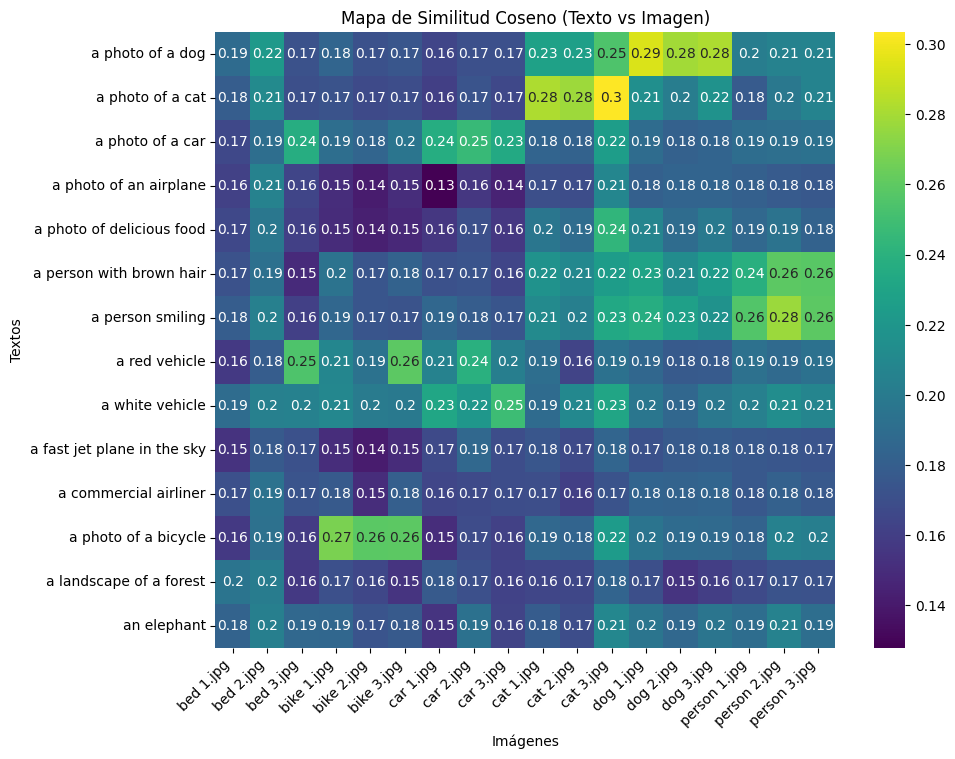

In [52]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(similarity, xticklabels=image_names, yticklabels=texts, annot=True, cmap='viridis')
plt.title("Mapa de Similitud Coseno (Texto vs Imagen)")
plt.xlabel("Imágenes")
plt.ylabel("Textos")
plt.xticks(rotation=45, ha='right')
plt.show()

#### 3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.

Aquí reducimos las dimensiones de los embeddings usando PCA o TSNE a 2 dimensiones para poder graficarlos con pyplot.

In [53]:
all_embeddings = torch.cat([image_embeddings, text_embeddings]).cpu().numpy()

# pca = PCA(n_components=2, n_oversamples=12)
pca = PCA(n_components=2)
embeddings_2d_pca = pca.fit_transform(all_embeddings)

img_2d_pca = embeddings_2d_pca[:len(image_embeddings)]
txt_2d_pca = embeddings_2d_pca[len(image_embeddings):]

tsne = TSNE(n_components=2, perplexity=12, random_state=42)
embeddings_2d_tsne = tsne.fit_transform(all_embeddings)

img_2d_tsne = embeddings_2d_tsne[:len(image_embeddings)]
txt_2d_tsne = embeddings_2d_tsne[len(image_embeddings):]

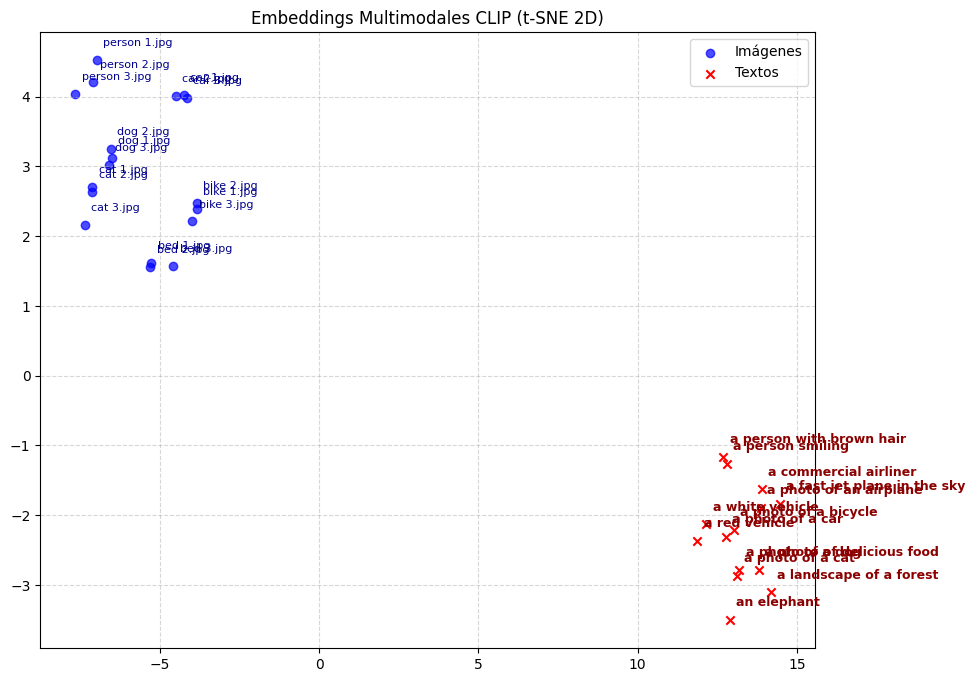

In [54]:
plt.figure(figsize=(10, 8))

# Graficar puntos de imágenes
plt.scatter(img_2d_tsne[:,0], img_2d_tsne[:,1], c='blue', marker='o', label='Imágenes', alpha=0.7)
for i, path in enumerate(image_paths):
    # os.path.basename toma "/kaggle/input/.../perro.jpg" y devuelve solo "perro.jpg"
    short_name = os.path.basename(path)
    plt.text(img_2d_tsne[i,0]+0.2, img_2d_tsne[i,1]+0.2, short_name, fontsize=8, color='darkblue')

# Graficar puntos de texto
plt.scatter(txt_2d_tsne[:,0], txt_2d_tsne[:,1], c='red', marker='x', label='Textos')
for i, txt in enumerate(texts):
    plt.text(txt_2d_tsne[i,0]+0.2, txt_2d_tsne[i,1]+0.2, txt, fontsize=9, color='darkred', weight='bold')

plt.title("Embeddings Multimodales CLIP (t-SNE 2D)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

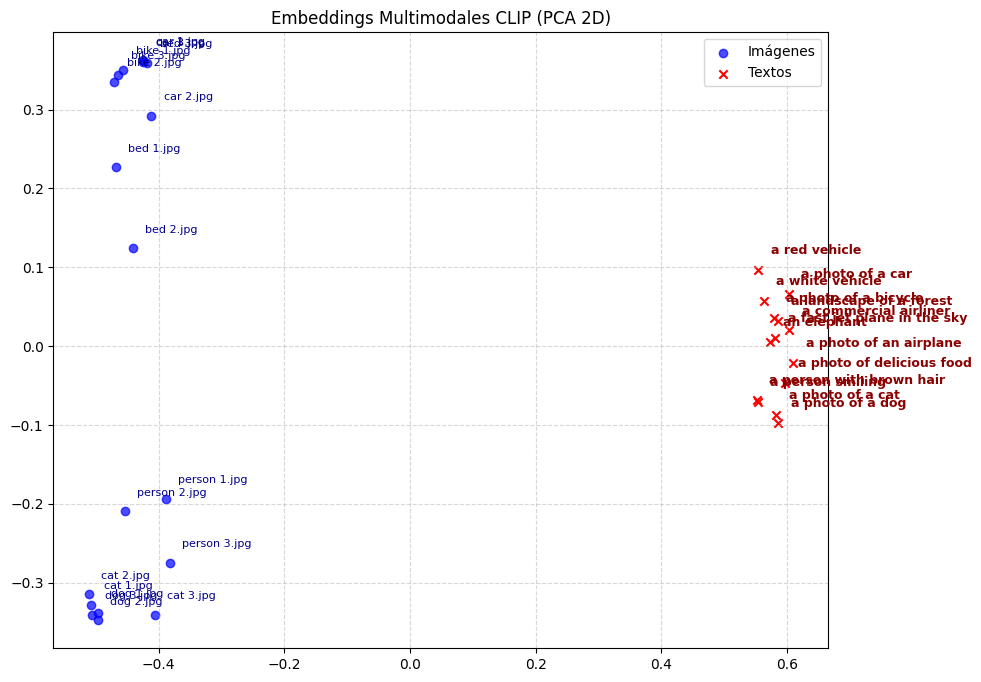

In [55]:
plt.figure(figsize=(10, 8))

# Graficar puntos de imágenes
plt.scatter(img_2d_pca[:,0], img_2d_pca[:,1], c='blue', marker='o', label='Imágenes', alpha=0.7)
for i, path in enumerate(image_paths):
    short_name = os.path.basename(path)
    plt.text(img_2d_pca[i,0]+0.02, img_2d_pca[i,1]+0.02, short_name, fontsize=8, color='darkblue')

# Graficar puntos de texto
plt.scatter(txt_2d_pca[:,0], txt_2d_pca[:,1], c='red', marker='x', label='Textos')
for i, txt in enumerate(texts):
    plt.text(txt_2d_pca[i,0]+0.02, txt_2d_pca[i,1]+0.02, txt, fontsize=9, color='darkred', weight='bold')

plt.title("Embeddings Multimodales CLIP (PCA 2D)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### 4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [56]:
def buscar_imagen(texto):
    token = clip.tokenize([texto]).to(device)

    with torch.no_grad():
        emb = model.encode_text(token)
        emb /= emb.norm(dim=-1, keepdim=True)

    scores = cosine_similarity(
        emb.cpu().numpy(),
        image_embeddings.cpu().numpy()
    )[0]

    idx = np.argmax(scores)

    print("Texto:", texto)
    print("Imagen más similar:", image_paths[idx])
    plt.imshow(Image.open(image_paths[idx]))
    plt.axis("off")
    plt.show()


In [57]:
def buscar_texto(nombre_imagen):
    img = preprocess(Image.open(nombre_imagen).convert("RGB")).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model.encode_image(img)
        emb /= emb.norm(dim=-1, keepdim=True)

    scores = cosine_similarity(
        emb.cpu().numpy(),
        text_embeddings.cpu().numpy()
    )[0]

    text_scores = zip(texts, scores)
    text_scores = sorted(text_scores, key=lambda x: x[1], reverse=True)
    print(text_scores)

    idx = np.argmax(scores)

    print("Imagen:", nombre_imagen)
    print("Texto más cercano:", texts[idx])
    plt.imshow(Image.open(nombre_imagen))
    plt.axis("off")
    plt.show()


#### Apartado de pruebas

Texto: pet
Imagen más similar: /kaggle/input/imagenesri/RI/cat 3.jpg


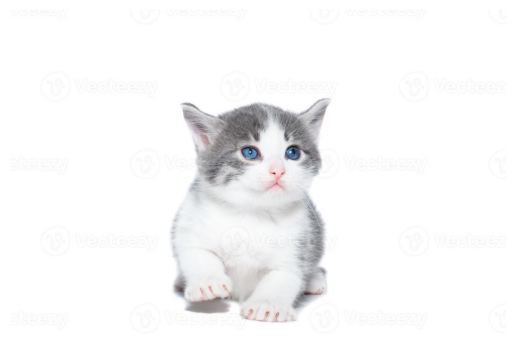

In [58]:
buscar_imagen("pet")

Texto: girl
Imagen más similar: /kaggle/input/imagenesri/RI/person 2.jpg


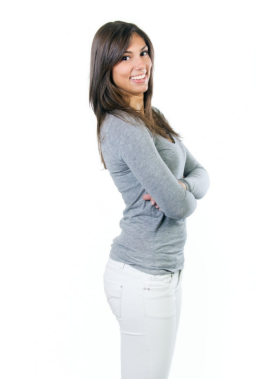

In [59]:
buscar_imagen("girl")

Texto: man with black shirt
Imagen más similar: /kaggle/input/imagenesri/RI/person 1.jpg


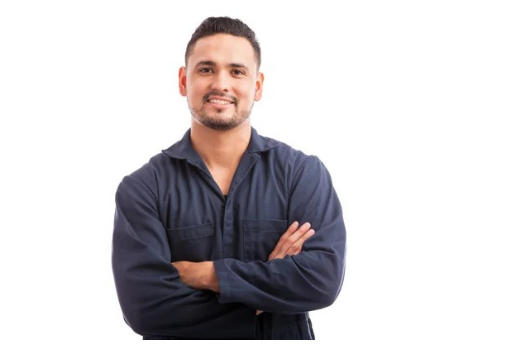

In [60]:
buscar_imagen("man with black shirt")

Texto: grandma
Imagen más similar: /kaggle/input/imagenesri/RI/person 3.jpg


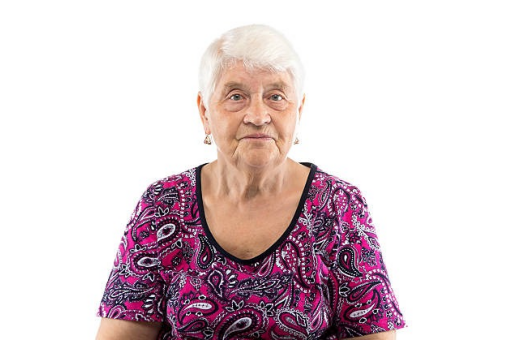

In [62]:
buscar_imagen("grandma")

Probando con la imagen: /kaggle/input/imagenesri/RI/person 1.jpg
[('a person smiling', np.float64(0.255705339733677)), ('a person with brown hair', np.float64(0.23878707638697055)), ('a white vehicle', np.float64(0.20344697645274173)), ('a photo of a dog', np.float64(0.20141876295688807)), ('a red vehicle', np.float64(0.19302184087067958)), ('a photo of a car', np.float64(0.1898161477755881)), ('an elephant', np.float64(0.18976081040285753)), ('a photo of delicious food', np.float64(0.18678442422290195)), ('a photo of a bicycle', np.float64(0.1833369450358211)), ('a photo of an airplane', np.float64(0.18076048340827783)), ('a photo of a cat', np.float64(0.17732614644247324)), ('a fast jet plane in the sky', np.float64(0.17551727512868137)), ('a commercial airliner', np.float64(0.17526483612908933)), ('a landscape of a forest', np.float64(0.16717169347637723))]
Imagen: /kaggle/input/imagenesri/RI/person 1.jpg
Texto más cercano: a person smiling


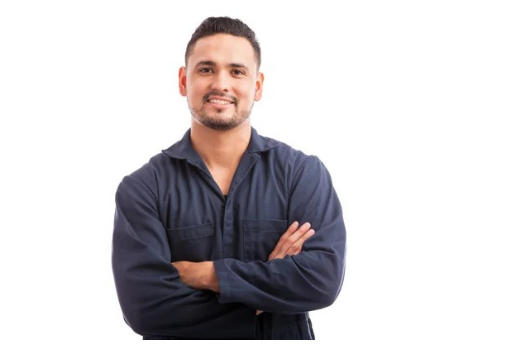

In [63]:
import random

# Elegimos una ruta al azar de tu lista de imágenes cargadas
imagen_aleatoria = random.choice(image_paths)

print(f"Probando con la imagen: {imagen_aleatoria}")
buscar_texto(imagen_aleatoria)

[('a photo of a car', np.float64(0.24638130132007913)), ('a red vehicle', np.float64(0.2391598647886693)), ('a white vehicle', np.float64(0.2209333646606444)), ('an elephant', np.float64(0.19318929536142332)), ('a fast jet plane in the sky', np.float64(0.1867951853626531)), ('a person smiling', np.float64(0.1786594248739207)), ('a photo of a cat', np.float64(0.1736384830387486)), ('a person with brown hair', np.float64(0.17351245444226454)), ('a landscape of a forest', np.float64(0.17102660598118066)), ('a photo of delicious food', np.float64(0.17089080594043393)), ('a photo of a dog', np.float64(0.17059515059455288)), ('a photo of a bicycle', np.float64(0.1679334947883406)), ('a commercial airliner', np.float64(0.16745533470132973)), ('a photo of an airplane', np.float64(0.15593217856106414))]
Imagen: /kaggle/input/imagenesri/RI/car 2.jpg
Texto más cercano: a photo of a car


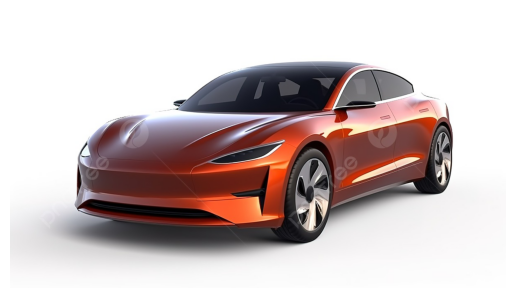

In [64]:
# Buscamos la ruta completa que contenga "auto1.jpg"
nombre_buscado = "car 2.jpg"

# Esto busca en la lista 'image_paths' la ruta que termina con ese nombre
ruta_encontrada = next((p for p in image_paths if nombre_buscado in p), None)

if ruta_encontrada:
    buscar_texto(ruta_encontrada)
else:
    print("No se encontró esa imagen en la lista.")